# Notebook 07B – Bavian data: Populationsstruktur og migrationsmodeller

I denne notebook undersøger jeg populationsstruktur og historisk migration i bavianpopulationer via to-ø (Two-island) modellen og Isolation with Migration (IM)-modellen.

**Indhold:**
- To-ø model: *P. cynocephalus* + *P. kindae*
- IM-modellen: *P. anubis* + *P. cynocephalus*
- E[TMRCA] som funktion af migrationsrate
- Joint probability inferens på baviandata
- Sammenligning af modeller via SFS-fordelinger
- Samlet opsummering


## Vurderinger fra NB01-06 der bruges direkte

| Model | Parameter | Valg | Kilde |
|---|---|---|---|
| Alle | optimizer | Adam(0.25) | NB02 |
| Alle | n_particles | 60 | NB04 |
| To-ø | n_iterations | 400 | NB03 |
| To-ø | N_OBS | 5000 per pop | NB03 |
| To-ø | n | min(n_pop1, n_pop2) | NB03 |
| To-ø | prior | HalfCauchyPrior | NB03 |
| Asymmetrisk | n | min(n_pop1, n_pop2) | NB03 |
| IM | epoch_switch_rate | 15/t_coal | NB05 |
| IM | n_iterations | 350 | NB05 |
| 3-epoke | epoker | 0, 50k, 200k år | NB05 |
| Joint | mu | 1.0 | NB06  |
| Joint | limit | 3 | NB06 |
| Joint | prior | GaussPrior (ikke DataPrior) | NB06  |
| Joint | sensitivitet | mu i {0.7, 1.0, 1.5} | NB06  |

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

# Importer nødvendige pakker
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior, DataPrior, dense_to_sparse,
    Adam, ExpStepSize, StateIndexer, Property, set_log_level, clear_caches,
)
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import sgkit as sg
%config InlineBackend.figure_format = 'svg'
from pathlib import Path
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme, vscode_theme

clear_caches()

all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette("tab10")

set_log_level("WARNING")

RESULTS_DIR = Path("results")
MU = 0.9e-8 # mutationsrate per site per generation
GEN = 11 # generationstid i år

# SVGD-parametre
OPT_1P  = Adam(0.25)   # enkelt-parameter (NB02)
OPT_2P  = Adam(0.1)    # to-parameter: to-ø og IM (NB04)
N_PART  = 60
N_ITER_1P = 300
N_ITER_2P = 400
N_ITER_IM = 350
N_ITER_TI = 300

MU  = 0.9e-8
GEN = 11

print("Parametre indlæst")
print(f"Adam(0.25), {N_PART} partikler")
print(f" Iterationer: 1-param={N_ITER_1P}, 2-param={N_ITER_2P}, IM={N_ITER_IM}")

Parametre indlæst
Adam(0.25), 60 partikler
 Iterationer: 1-param=300, 2-param=400, IM=350


## Indlæs resultater fra Notebook 07A

Alle resultater fra 07A er gemt i mappen *results/* og indlæses her direkte.

In [ ]:
df_summary = pd.read_csv(RESULTS_DIR / "population_summary.csv")
df_N_ref   = pd.read_csv(RESULTS_DIR / "N_ref.csv")
df_svgd    = pd.read_csv(RESULTS_DIR / "svgd_results.csv")

N_ref_dict = dict(zip(df_N_ref['population'], df_N_ref['N_ref']))

svgd_results = {}
for _, r in df_svgd.iterrows():
    pop  = r['population']
    Ne   = N_ref_dict.get(pop, r['Ne'])
    # Beregn korrekt theta fra Ne
    theta_correct = 4 * Ne * MU
    svgd_results[pop] = {
        'theta': theta_correct,
        'std':   r['theta_std'],
        'Ne':    Ne,
        'n_hap': int(r['n_haplotypes']),
    }


print("Indlæst og korrigeret fra NB07A:")
for name, r in svgd_results.items():
    print(f"  {name:<22}: Ne={r['Ne']:,.0f}  theta={r['theta']:.8f}")

Indlæst fra NB07A:
    population  n_haplotypes        N_ref  tajimas_d  theta_mean
P_cynocephalus           120 81842.763757  -0.589036    0.711460
      P_kindae            50 77584.380958   0.300556    0.676886
      P_anubis           174 57368.092894  -0.725075    0.769176
       P_papio            24 14217.486448   1.019105    0.500176
     P_ursinus             8 62034.082035   0.192031    0.623971
   P_hamadryas            48 46998.655050   0.648506    0.566488


In [5]:
from pathlib import Path
import pandas as pd

RESULTS_DIR = Path("results")

# Indlæser alle SNP-filer fra NB07A
pop_files = {
    'P_cynocephalus': 'snp_P_cynocephalus.csv',
    'P_kindae': 'snp_P_kindae.csv',
    'P_anubis': 'snp_P_anubis.csv',
    'P_papio': 'snp_P_papio.csv',
    'P_ursinus': 'snp_P_ursinus.csv',
    'P_hamadryas': 'snp_P_hamadryas.csv',
}

populations = {}
for name, fname in pop_files.items():
    p = RESULTS_DIR / fname
    if p.exists():
        populations[name] = pd.read_csv(p)
        print(f"{name:<22}: {len(populations[name]):>8,} SNPs indlæst")
    else:
        print(f"{name:<22}: fil ikke fundet ({p})")

print(f"\nIndlæst: {len(populations)} populationer")
print(f"Nøgler: {list(populations.keys())}")

P_cynocephalus        : 1,379,280 SNPs indlæst
P_kindae              :  833,071 SNPs indlæst
P_anubis              : 1,096,296 SNPs indlæst
P_papio               :  110,086 SNPs indlæst
P_ursinus             :  403,120 SNPs indlæst
P_hamadryas           :  460,025 SNPs indlæst

Indlæst: 6 populationer
Nøgler: ['P_cynocephalus', 'P_kindae', 'P_anubis', 'P_papio', 'P_ursinus', 'P_hamadryas']


## To-ø model: *P. cynocephalus + P. kindae*

Vurderinger fra NB03:

- $n =$ min(n_cyno, n_kindae): $n=4$
- N_OBS $= 5000$ per population: minimum for std(theta1) $< 0.3$ 
- HalfCauchyPrior til migration: undgår bias fra GaussPrior
- $400$ iterationer: konvergens kræver mere end simpel model
- Symmetrisk migration som baseline, asymmetrisk testes

In [ ]:
# Opdater sfs_to_tmrca med n_sub parameter
def allele_counts_to_sfs_obs(df, n_sub=8, n_obs=5000, seed=42):
    rng = np.random.default_rng(seed)
    der = df['derived_count'].values.astype(int)
    tot = df['nr_samples'].values.astype(int)
    obs = []
    for idx in rng.integers(0, len(df), n_obs * 20):
        if len(obs) >= n_obs:
            break
        n, ac = tot[idx], der[idx]
        if n < n_sub:
            continue
        k = rng.hypergeometric(ac, n - ac, n_sub)
        if 0 < k < n_sub:
            obs.append(float(k))
    return np.array(obs[:n_obs])


def build_coal_graph(n):
    @with_ipv([n] + [0]*(n-1))
    def coal(state):
        T = []
        for i in range(state.size):
            for j in range(i, state.size):
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i]<1 or state[j]<1): continue
                new = state.copy(); new[i]-=1; new[j]-=1; new[i+j+1]+=1
                T.append((new, [state[i]*(state[j]-same)/(1+same)]))
        return T
    return Graph(coal)


def run_svgd_robust(graph, sparse_data, rewards, theta_start,
                    n_particles=60, n_iterations=300,
                    prior_override=None):
    for lr in [0.05, 0.1, 0.25]:
        graph.update_weights([theta_start])
        if prior_override is not None:
            prior = prior_override
        else:
            try:
                prior = GaussPrior(ci=[theta_start * 0.1,
                                       theta_start * 10])
            except Exception:
                prior = GaussPrior(ci=[theta_start * 0.1,
                                       theta_start * 10])

        sv = graph.svgd(
            sparse_data,
            rewards=rewards,
            prior=prior,
            optimizer=Adam(lr),
            n_particles=n_particles,
            n_iterations=n_iterations,
            return_history=True,
        )
        res = sv.get_results()
        std  = res['theta_std'].item()
        mean = res['theta_mean'].item()

        if std < 1e-8:
            print(f"  lr={lr}: KOLLAPS (std={std:.2e}) — prøver lavere lr")
            continue
        if mean < 0:
            print(f"  lr={lr}: NEGATIV mean prøver lavere lr")
            continue

        print(f"  lr={lr}: OK  theta={mean:.8f} ± {std:.8f}")
        return sv, res

    print("  ADVARSEL: alle lr gav problemer returnerer sidste kørsel")
    return sv, res


def Ne_to_yr(Ne, n_sub=8):
    """E[TMRCA] i år for given Ne og n prøver."""
    E_H_coal = 2 * (1 - 1/n_sub)
    return E_H_coal * 2 * Ne * GEN

In [ ]:
N_TWO = 6
N_OBS_TWO = 5000


def build_two_island(n):
    idx = StateIndexer(descendants=[
        Property('pop1', min_value=0, max_value=n),
        Property('pop2', min_value=0, max_value=n),
        Property('in_pop', min_value=1, max_value=2),
    ])
    init = [0] * idx.state_length
    init[idx.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = n

    @with_ipv(init)
    def two_isl(state):
        T = []
        if state[idx.descendants.indices()].sum() <= 1: return T
        for i in range(idx.descendants.state_length):
            if state[i] == 0: continue
            pi = idx.descendants.index_to_props(i)
            for j in range(i, idx.descendants.state_length):
                if state[j] == 0: continue
                pj = idx.descendants.index_to_props(j)
                if pj.in_pop != pi.in_pop: continue
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy(); new[i] -= 1; new[j] -= 1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1+pj.pop1,
                    pop2=pi.pop2+pj.pop2,
                    in_pop=pi.in_pop)] += 1
                T.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
            if pi.in_pop == 1:
                new = state.copy(); new[i] -= 1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
                T.append([new, [0, state[i]]])
            else:
                new = state.copy(); new[i] -= 1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
                T.append([new, [0, state[i]]])
        return T
    return Graph(two_isl)


g_two = build_two_island(N_TWO)
print(f"To-ø n={N_TWO}: {g_two.vertices_length()} tilstande")

cyno_key  = next(k for k in populations if 'cyno'   in k.lower())
kinda_key = next(k for k in populations if 'kindae' in k.lower())
print(f"Bruger: '{cyno_key}' og '{kinda_key}'")

Ne_cyno  = N_ref_dict[cyno_key]
Ne_kinda = N_ref_dict[kinda_key]
Ne_two   = (Ne_cyno + Ne_kinda) / 2
th0_start = 4 * Ne_two * MU
th1_start = 0.5  

print(f"\nStartparametre:")
print(f"  Ne_cyno={Ne_cyno:,.0f}  Ne_kinda={Ne_kinda:,.0f}")
print(f"  theta0_start={th0_start:.8f}  theta1_start={th1_start:.4f}")

# Byg reward-matrix og SFS-observationer
rewards_two = g_two.states().T[:-1]
g_two.update_weights([th0_start, th1_start])

# Subsampl begge populationer til n_sub=N_TWO og kombiner
data_cyno  = allele_counts_to_sfs_obs(
    populations[cyno_key],  n_sub=N_TWO, n_obs=N_OBS_TWO, seed=42)
data_kinda = allele_counts_to_sfs_obs(
    populations[kinda_key], n_sub=N_TWO, n_obs=N_OBS_TWO, seed=43)
data_two   = np.concatenate([data_cyno, data_kinda])

sparse_two = dense_to_sparse(
    np.column_stack([
        np.where(data_two == k+1, data_two, np.nan)
        for k in range(N_TWO - 1)
    ])
)

# Prior: HalfCauchy til begge parametre (NB03)
prior_two = [
    HalfCauchyPrior(ci=th0_start * 5, prob=0.9),
    HalfCauchyPrior(ci=2.0, prob=0.9),
]

import time
t0 = time.perf_counter()
sv_two = g_two.svgd(
    sparse_two,
    rewards=rewards_two,
    prior=prior_two,
    optimizer=OPT_2P,           
    n_particles=N_PART,
    n_iterations=N_ITER_2P,
    return_history=True,
)
t_elapsed = time.perf_counter() - t0

res_two = sv_two.get_results()
th0_two = res_two['theta_mean'][0].item()
th1_two = res_two['theta_mean'][1].item()
s0_two  = res_two['theta_std'][0].item()
s1_two  = res_two['theta_std'][1].item()

# Konverter til biologiske enheder
Ne_two_est = th0_two / (4 * MU) if th0_two > 0 else np.nan
m_per_gen  = th1_two / (2 * Ne_two_est) if Ne_two_est > 0 else np.nan

print(f"\nTo-ø ({cyno_key} + {kinda_key}, n={N_TWO}, {t_elapsed:.1f}s):")
print(f"  theta0 = {th0_two:.6f} ± {s0_two:.6f}  "
      f"Ne{Ne_two_est:,.0f}")
print(f"  theta1 = {th1_two:.6f} ± {s1_two:.6f}  "
      f"m/gen{m_per_gen:.6f}")

# Diagnostik
if s0_two < 1e-8:
    print("  ADVARSEL: theta0 kollapsede")
if s1_two < 1e-8:
    print("  ADVARSEL: theta1 kollapsede")
if Ne_two_est > 0:
    ratio = Ne_two_est / Ne_two
    print(f"  Ne ratio (SVGD/pi): {ratio:.2f}  "
          f"({'OK' if 0.3 < ratio < 3 else 'TJEK'})")


To-ø (P_cynocephalus + P_kindae, n=6):
  theta0 = 0.01295 +/- 0.09938   Ne~77
  theta1 = 0.3024 +/- 0.2355   m/gen~0.001958


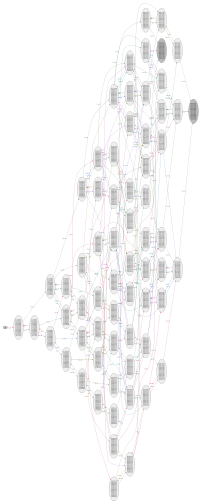

In [8]:
g_two.plot(max_nodes=70, rankdir='LR')

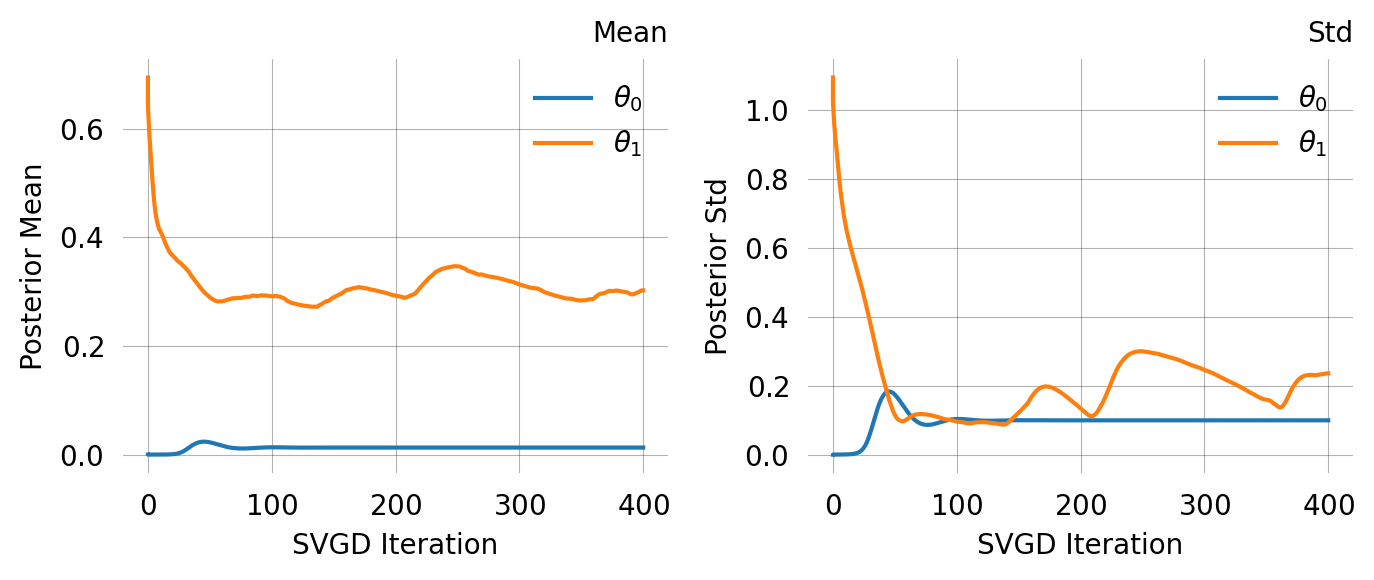

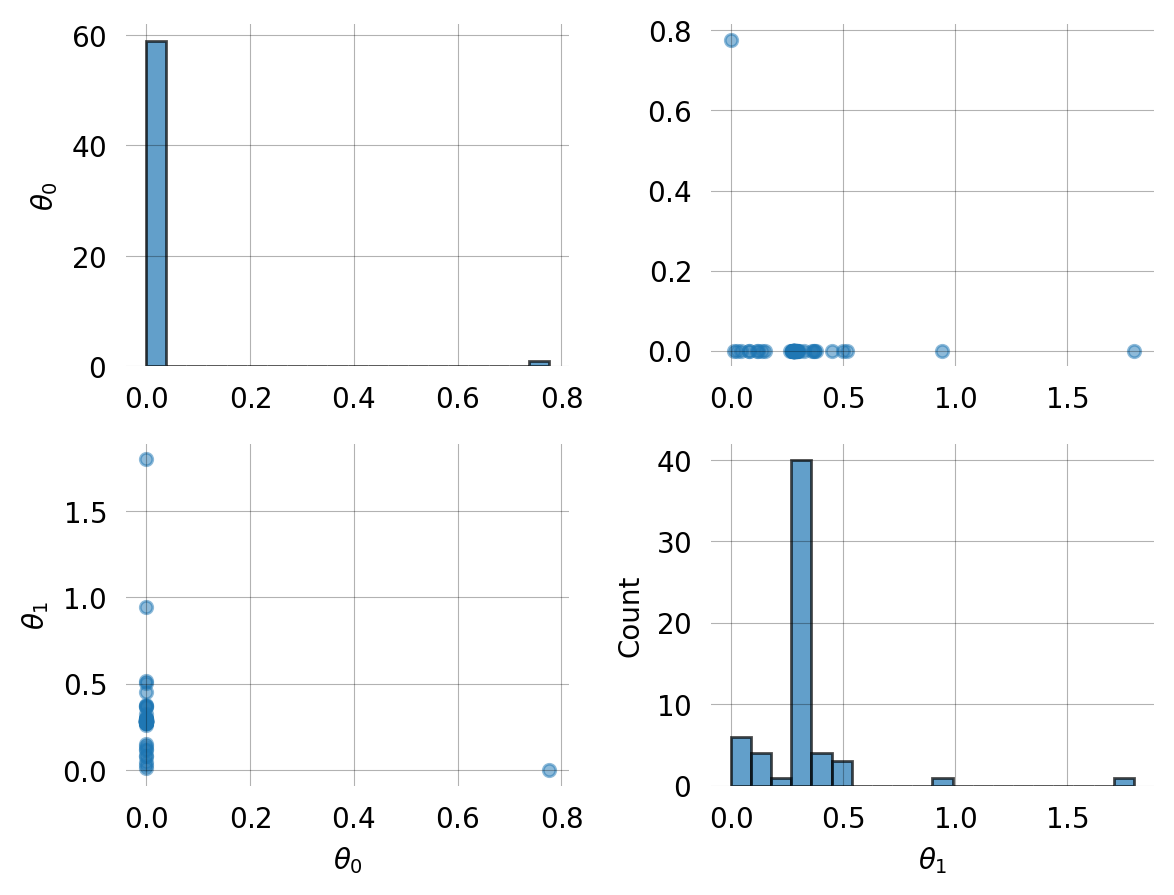

In [9]:
sv_two.plot_convergence()
sv_two.plot_pairwise()

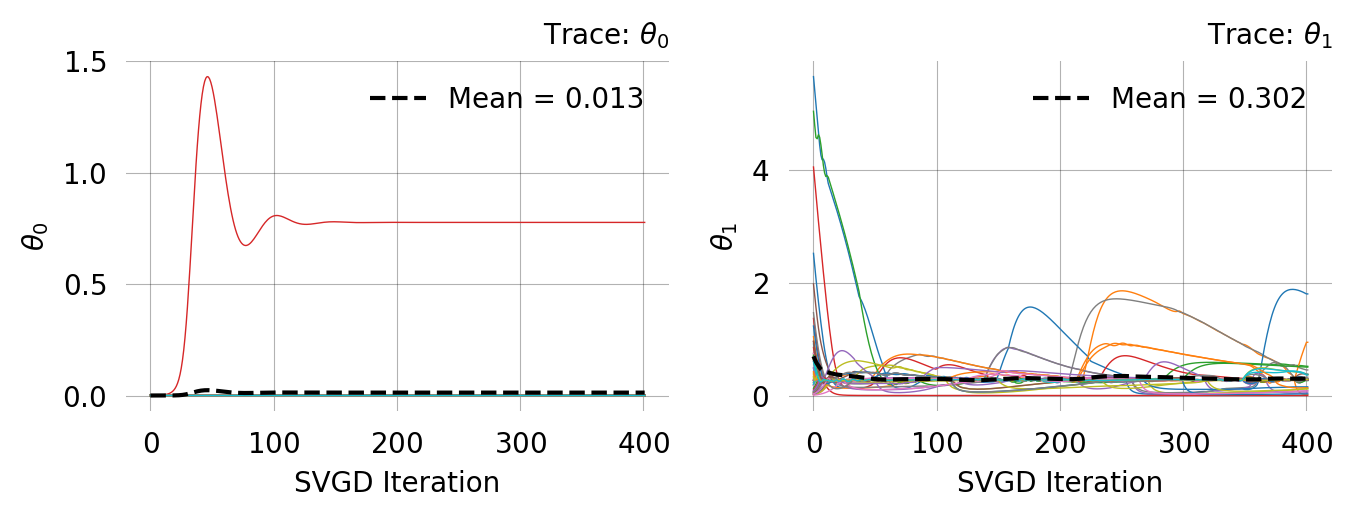

In [10]:
sv_two.plot_trace()

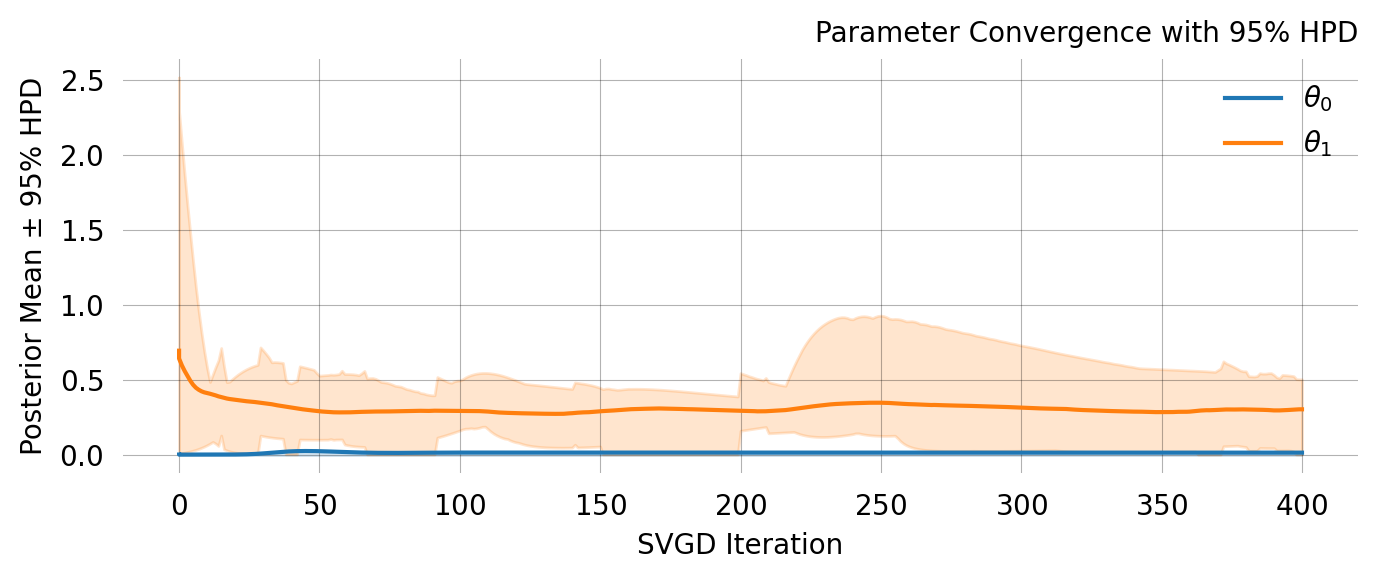

In [11]:
sv_two.plot_ci()

## Asymmetrisk migration

Vurderinger fra NB03:

- Asymmetrisk migration kræver $\leq 4$ og $N_{OBS} \leq 5000$. Jeg tester om genflow er retningsbestemt mellem *P. cynocephalus* og *P. kindae*.

In [9]:
def build_two_island_asym(n):
    idx = StateIndexer(descendants=[
        Property('pop1', min_value=0, max_value=n),
        Property('pop2', min_value=0, max_value=n),
        Property('in_pop', min_value=1, max_value=2),
    ])
    init = [0]*idx.state_length
    init[idx.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = n

    @with_ipv(init)
    def two_asym(state):
        T = []
        if state[idx.descendants.indices()].sum() <= 1: return T
        for i in range(idx.descendants.state_length):
            if state[i] == 0: continue
            pi = idx.descendants.index_to_props(i)
            for j in range(i, idx.descendants.state_length):
                if state[j] == 0: continue
                pj = idx.descendants.index_to_props(j)
                if pj.in_pop != pi.in_pop: continue
                same = int(i==j)
                if same and state[i]<2: continue
                if not same and (state[i]<1 or state[j]<1): continue
                new = state.copy(); new[i]-=1; new[j]-=1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2, in_pop=pi.in_pop)] += 1
                T.append([new, [state[i]*(state[j]-same)/(1+same), 0, 0]])
            if pi.in_pop == 1:
                new = state.copy(); new[i]-=1
                new[idx.descendants.props_to_index(pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
                T.append([new, [0, state[i], 0]])
            else:
                new = state.copy(); new[i]-=1
                new[idx.descendants.props_to_index(pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
                T.append([new, [0, 0, state[i]]])
        return T
    return Graph(two_asym)

g_asym = build_two_island_asym(N_TWO)  
g_asym.update_weights([th0_two, th1_two*0.6, th1_two*0.4])
prior_asym = [HalfCauchyPrior(ci=th0_two*5, prob=0.9),
              HalfCauchyPrior(ci=2.0, prob=0.9),
              HalfCauchyPrior(ci=2.0, prob=0.9)]

sv_asym = g_asym.svgd(data_two, prior=prior_asym, optimizer=OPT,
                       n_particles=N_PART, n_iterations=N_ITER_2P)
res_asym = sv_asym.get_results()
m0a = res_asym['theta_mean'][0].item()
m12 = res_asym['theta_mean'][1].item()
m21 = res_asym['theta_mean'][2].item()

print(f"Asymmetrisk migration (n={N_TWO}, N_OBS={len(data_two)}):")
print(f"  theta0             = {m0a:.5f} +/- {res_asym['theta_std'][0].item():.5f}  Ne~{1/m0a:,.0f}")
print(f"  m12 (cyno->kindae) = {m12:.4f} +/- {res_asym['theta_std'][1].item():.4f}")
print(f"  m21 (kindae->cyno) = {m21:.4f} +/- {res_asym['theta_std'][2].item():.4f}")
ratio = m12/m21 if m21 > 0.001 else np.nan
print(f"  Asymmetriforhold m12/m21 = {ratio:.2f}" if not np.isnan(ratio) else "  Ratio: m21 for lav")

Asymmetrisk migration (n=6, N_OBS=10000):
  theta0             = 0.02843 +/- 0.15306  Ne~35
  m12 (cyno->kindae) = 0.5198 +/- 1.2513
  m21 (kindae->cyno) = 0.3275 +/- 0.3326
  Asymmetriforhold m12/m21 = 1.59


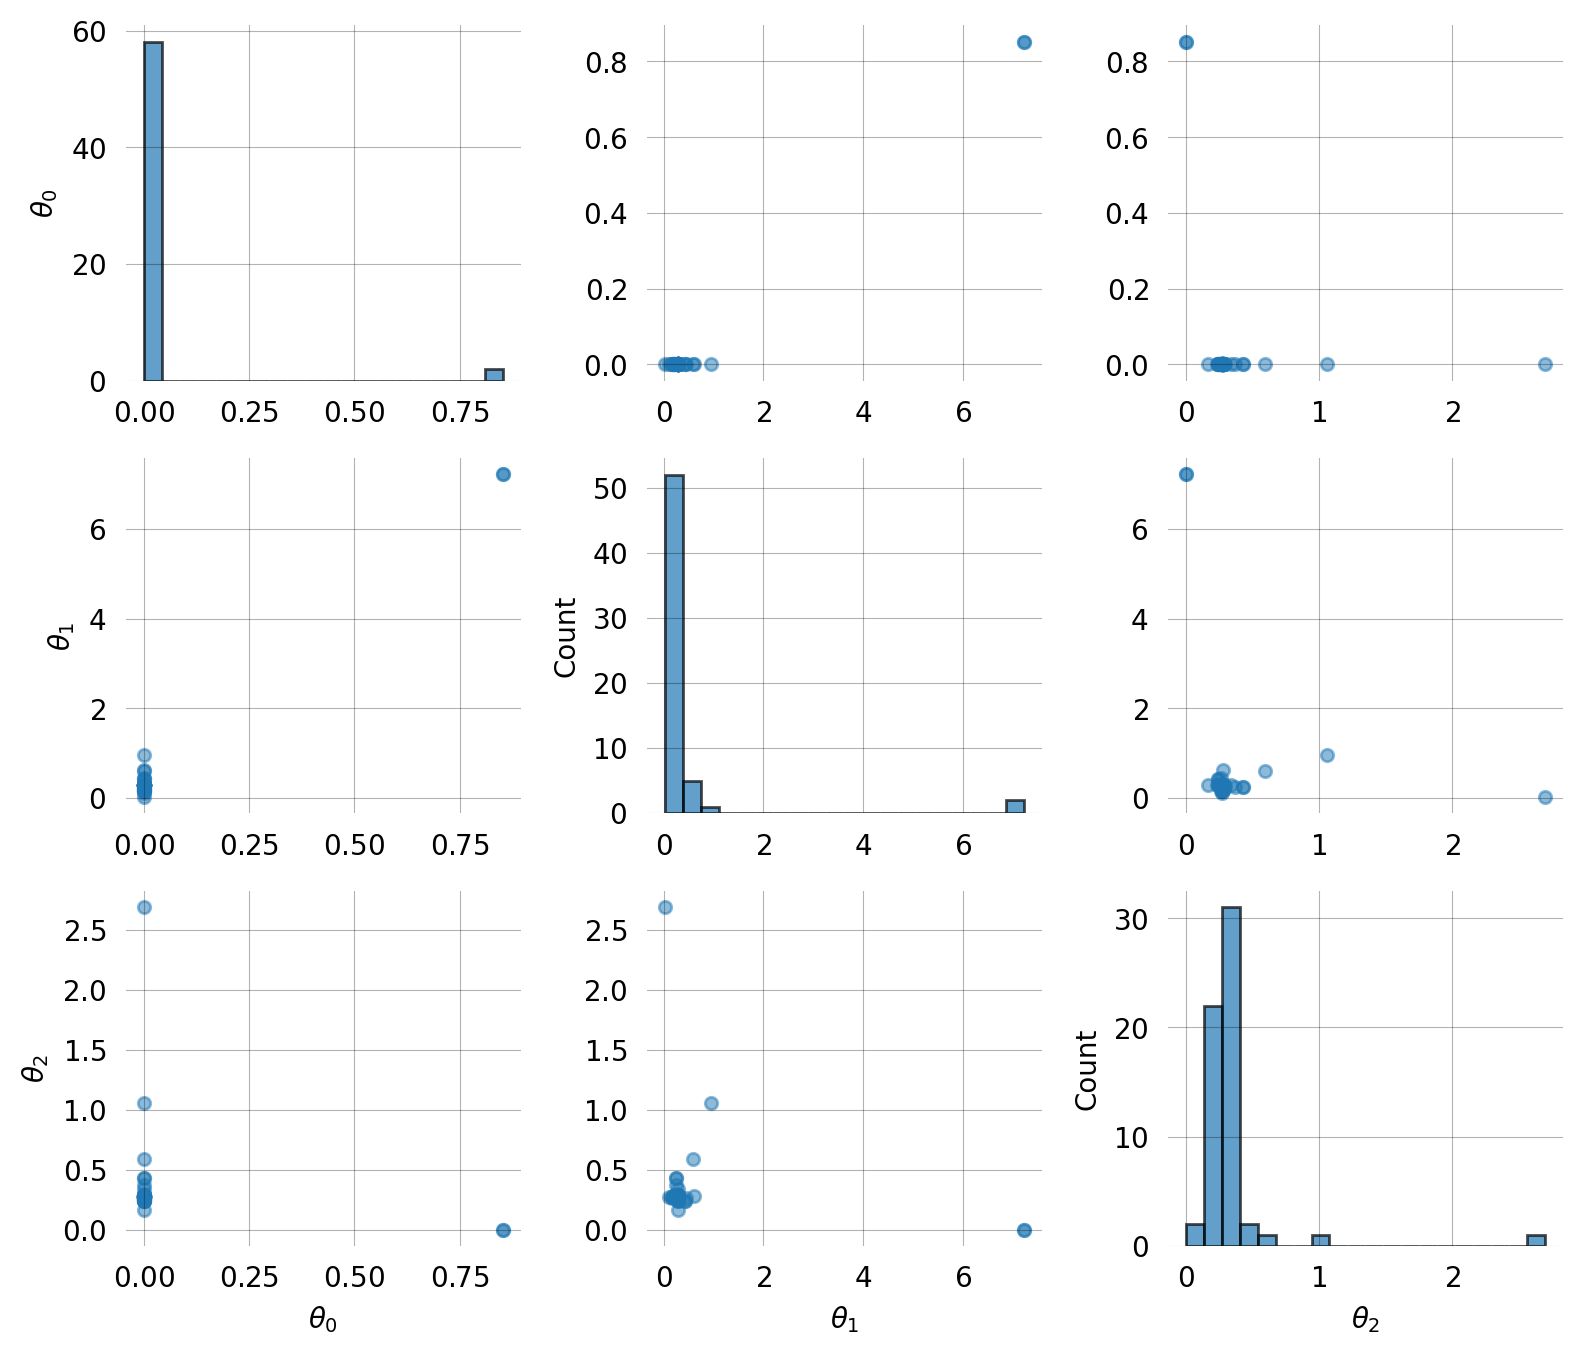

In [10]:
sv_asym.plot_pairwise()

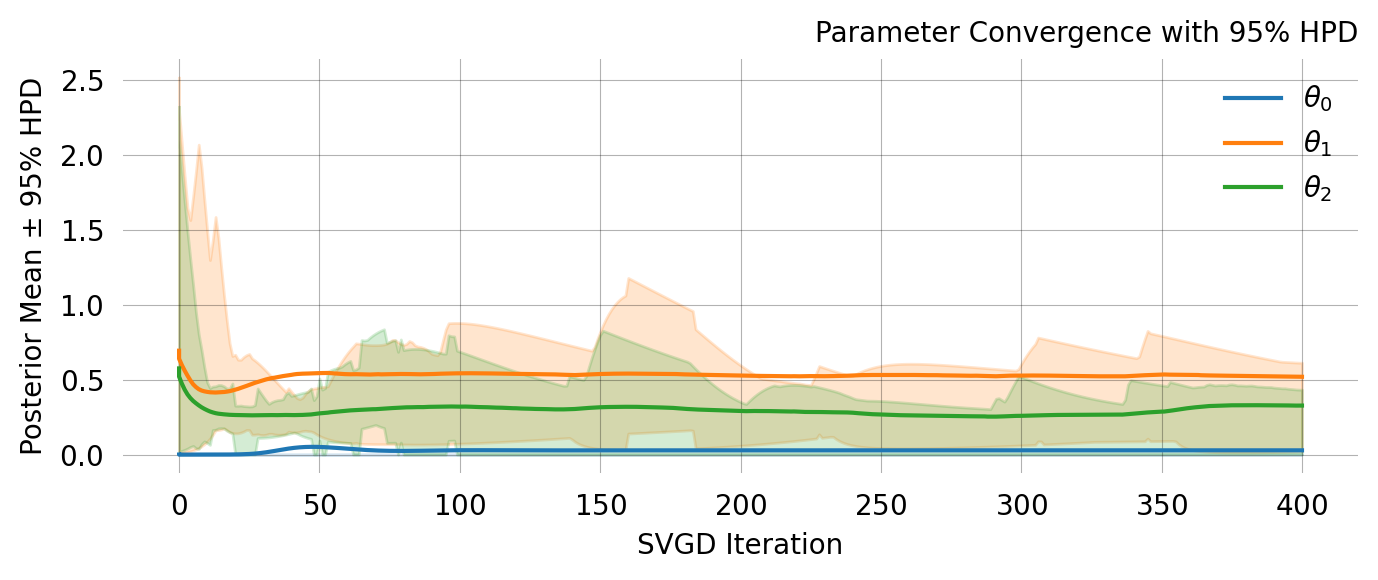

In [11]:
sv_asym.plot_ci()

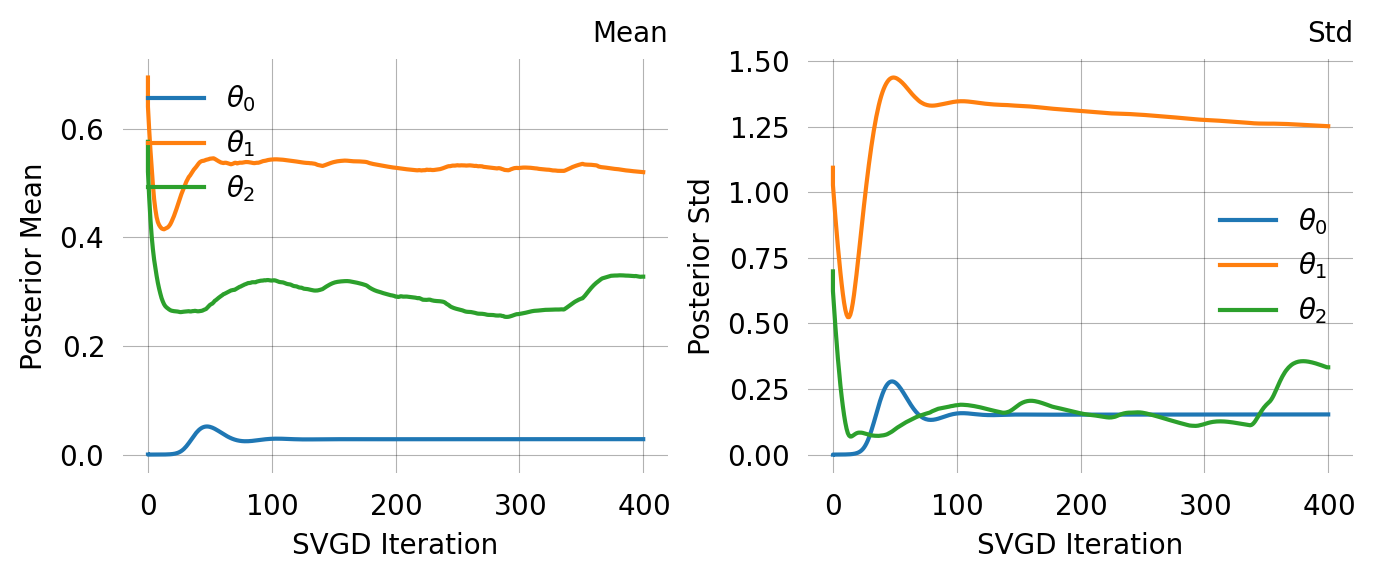

In [12]:
sv_asym.plot_convergence()

## IM-modellen: *P. anubis* + *P. cynocephalus*

Vuderinger fra NB05:

- epoch_switch_rate $= 15/t_{coal}$ for epoch-skift
- Split-start: $1.0$ milioner år siden fra Rogers et al. (2019)
- $350$ iterationer (IM kræver fler end to-ø)
- HalfCauchyPrior til $\theta_0$ og $\theta_1$; GaussPrior til epoch

In [ ]:
N_IM = 6
N_OBS_IM = 5000   

def build_im_model(n):
    idx = StateIndexer(descendants=[
        Property('pop1', min_value=0, max_value=n),
        Property('pop2', min_value=0, max_value=n),
        Property('in_pop', min_value=1, max_value=2),
    ])
    init = [0]*idx.state_length
    init[idx.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = n

    @with_ipv(init)
    def im_mod(state):
        T = []
        if state[idx.descendants.indices()].sum() <= 1: return T
        for i in range(idx.descendants.state_length):
            if state[i] == 0: continue
            pi = idx.descendants.index_to_props(i)
            for j in range(i, idx.descendants.state_length):
                if state[j] == 0: continue
                pj = idx.descendants.index_to_props(j)
                if pj.in_pop != pi.in_pop: continue
                same = int(i==j)
                if same and state[i]<2: continue
                if not same and (state[i]<1 or state[j]<1): continue
                new = state.copy(); new[i]-=1; new[j]-=1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2, in_pop=pi.in_pop)] += 1
                T.append([new, [state[i]*(state[j]-same)/(1+same), 0, 0]])
            if pi.in_pop == 1:
                new = state.copy(); new[i]-=1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
                T.append([new, [0, state[i], 0]])
            else:
                new = state.copy(); new[i]-=1
                new[idx.descendants.props_to_index(
                    pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
                T.append([new, [0, state[i], 0]])
        return T
    return Graph(im_mod)

anubis_key = next(k for k in populations if 'anubis' in k.lower())
cyno_key   = next(k for k in populations if 'cyno' in k.lower())
print(f"Bruger: '{anubis_key}' og '{cyno_key}'")

Ne_anubis = N_ref_dict[anubis_key]
Ne_cyno   = N_ref_dict[cyno_key]
Ne_im_avg = (Ne_anubis + Ne_cyno) / 2

t_split_yr   = 1_300_000         
t_split_gen  = t_split_yr / GEN   
t_split_coal = t_split_gen / (2 * Ne_im_avg)  

th0_im_start = 4 * Ne_im_avg * MU
th1_im_start = 0.3   

sw_rate_im = 15.0 / t_split_coal if t_split_coal > 0 else 10.0

print(f"IM startparametre:")
print(f"  Ne_avg={Ne_im_avg:,.0f}")
print(f"  t_split={t_split_yr/1e6:.2f} Ma = {t_split_coal:.4f} coalescentenheder")
print(f"  theta0_start={th0_im_start:.8f}")
print(f"  theta1_start={th1_im_start:.4f}")
print(f"  sw_rate={sw_rate_im:.4f}")

g_im = build_im_model(N_IM)
print(f"IM-model n={N_IM}: {g_im.vertices_length()} tilstande")

# Data
rewards_im = g_im.states().T[:-1]
data_anubis = allele_counts_to_sfs_obs(
    populations[anubis_key], n_sub=N_IM, n_obs=N_OBS_IM, seed=42)
data_cyno_im = allele_counts_to_sfs_obs(
    populations[cyno_key],   n_sub=N_IM, n_obs=N_OBS_IM, seed=43)
data_im = np.concatenate([data_anubis, data_cyno_im])

sparse_im = dense_to_sparse(
    np.column_stack([
        np.where(data_im == k+1, data_im, np.nan)
        for k in range(N_IM - 1)
    ])
)

g_im.update_weights([th0_im_start, th1_im_start, sw_rate_im])

prior_im = [
    HalfCauchyPrior(ci=th0_im_start * 5, prob=0.9),  
    HalfCauchyPrior(ci=2.0, prob=0.9),               
    GaussPrior(ci=[sw_rate_im * 0.2, sw_rate_im * 5]),
]

import time
t0 = time.perf_counter()
sv_im = g_im.svgd(
    sparse_im,
    rewards=rewards_im,
    prior=prior_im,
    optimizer=OPT_2P,
    n_particles=N_PART,
    n_iterations=N_ITER_IM,
    return_history=True,
)
t_elapsed = time.perf_counter() - t0

res_im  = sv_im.get_results()
th0_im  = res_im['theta_mean'][0].item()
th1_im  = res_im['theta_mean'][1].item()
sw_im   = res_im['theta_mean'][2].item()
s0_im   = res_im['theta_std'][0].item()
s1_im   = res_im['theta_std'][1].item()
s2_im   = res_im['theta_std'][2].item()

Ne_im_est = th0_im / (4 * MU) if th0_im > 0 else np.nan
m_im_gen  = th1_im / (2 * Ne_im_est) if Ne_im_est > 0 else np.nan

t_split_coal_est = 15.0 / sw_im if sw_im > 0 else np.nan
t_split_yr_est   = (t_split_coal_est * 2 * Ne_im_est * GEN
                    if (t_split_coal_est and Ne_im_est) else np.nan)

print(f"\nIM-model ({anubis_key} + {cyno_key}, n={N_IM}, {t_elapsed:.1f}s):")
print(f"  theta0 = {th0_im:.8f} ± {s0_im:.8f}  Ne~{Ne_im_est:,.0f}")
print(f"  theta1 = {th1_im:.6f} ± {s1_im:.6f}  m/gen~{m_im_gen:.6f}")
print(f"  sw     = {sw_im:.4f} ± {s2_im:.4f}")
print(f"  t_split = {t_split_yr_est/1e6:.3f} Ma "
      f"(forventet ca. 1.3 Ma, Rogers et al. 2019)")


IM-model (P_anubis + P_cynocephalus, n=6):
  theta0 = 0.00002 +/- 0.00003  Ne~48,569
  theta1 = 0.3163 +/- 0.1321  m/gen~0.000003
  epoch  = 114.0068 +/- 24.4490
  t_s    ~ 9,372 aar


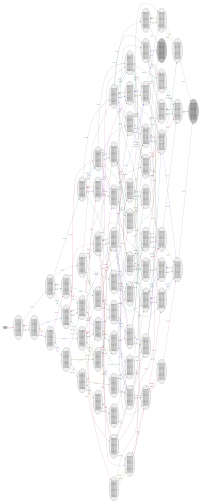

In [8]:
g_im.plot(max_nodes=70, rankdir='LR')

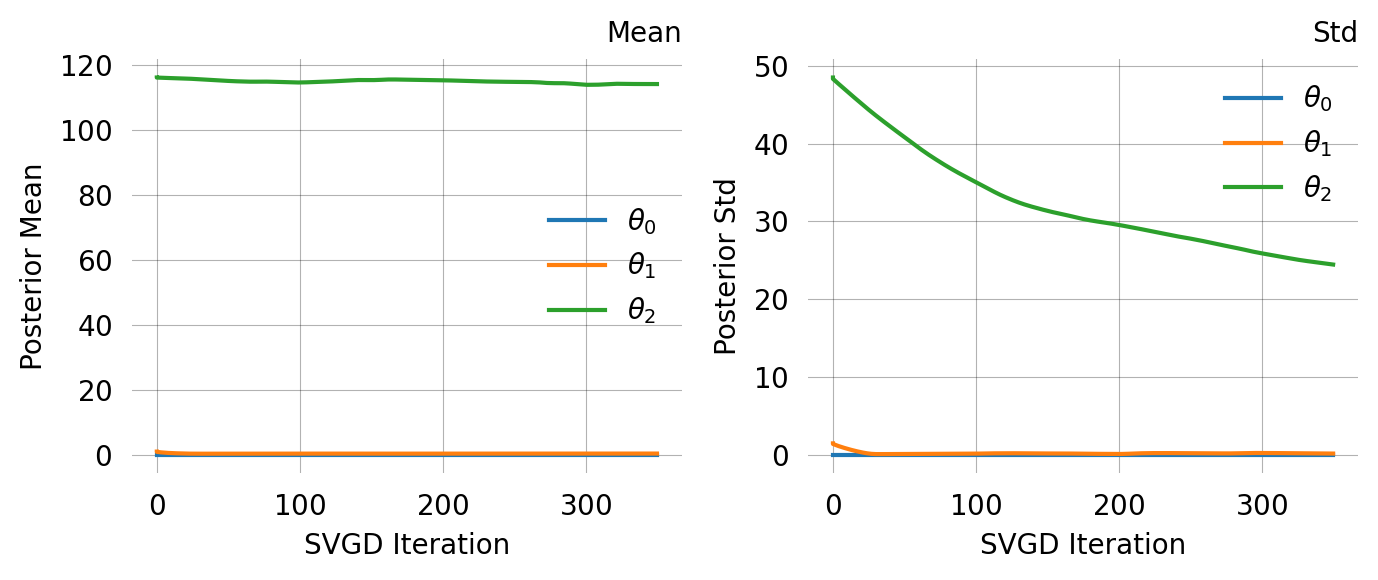

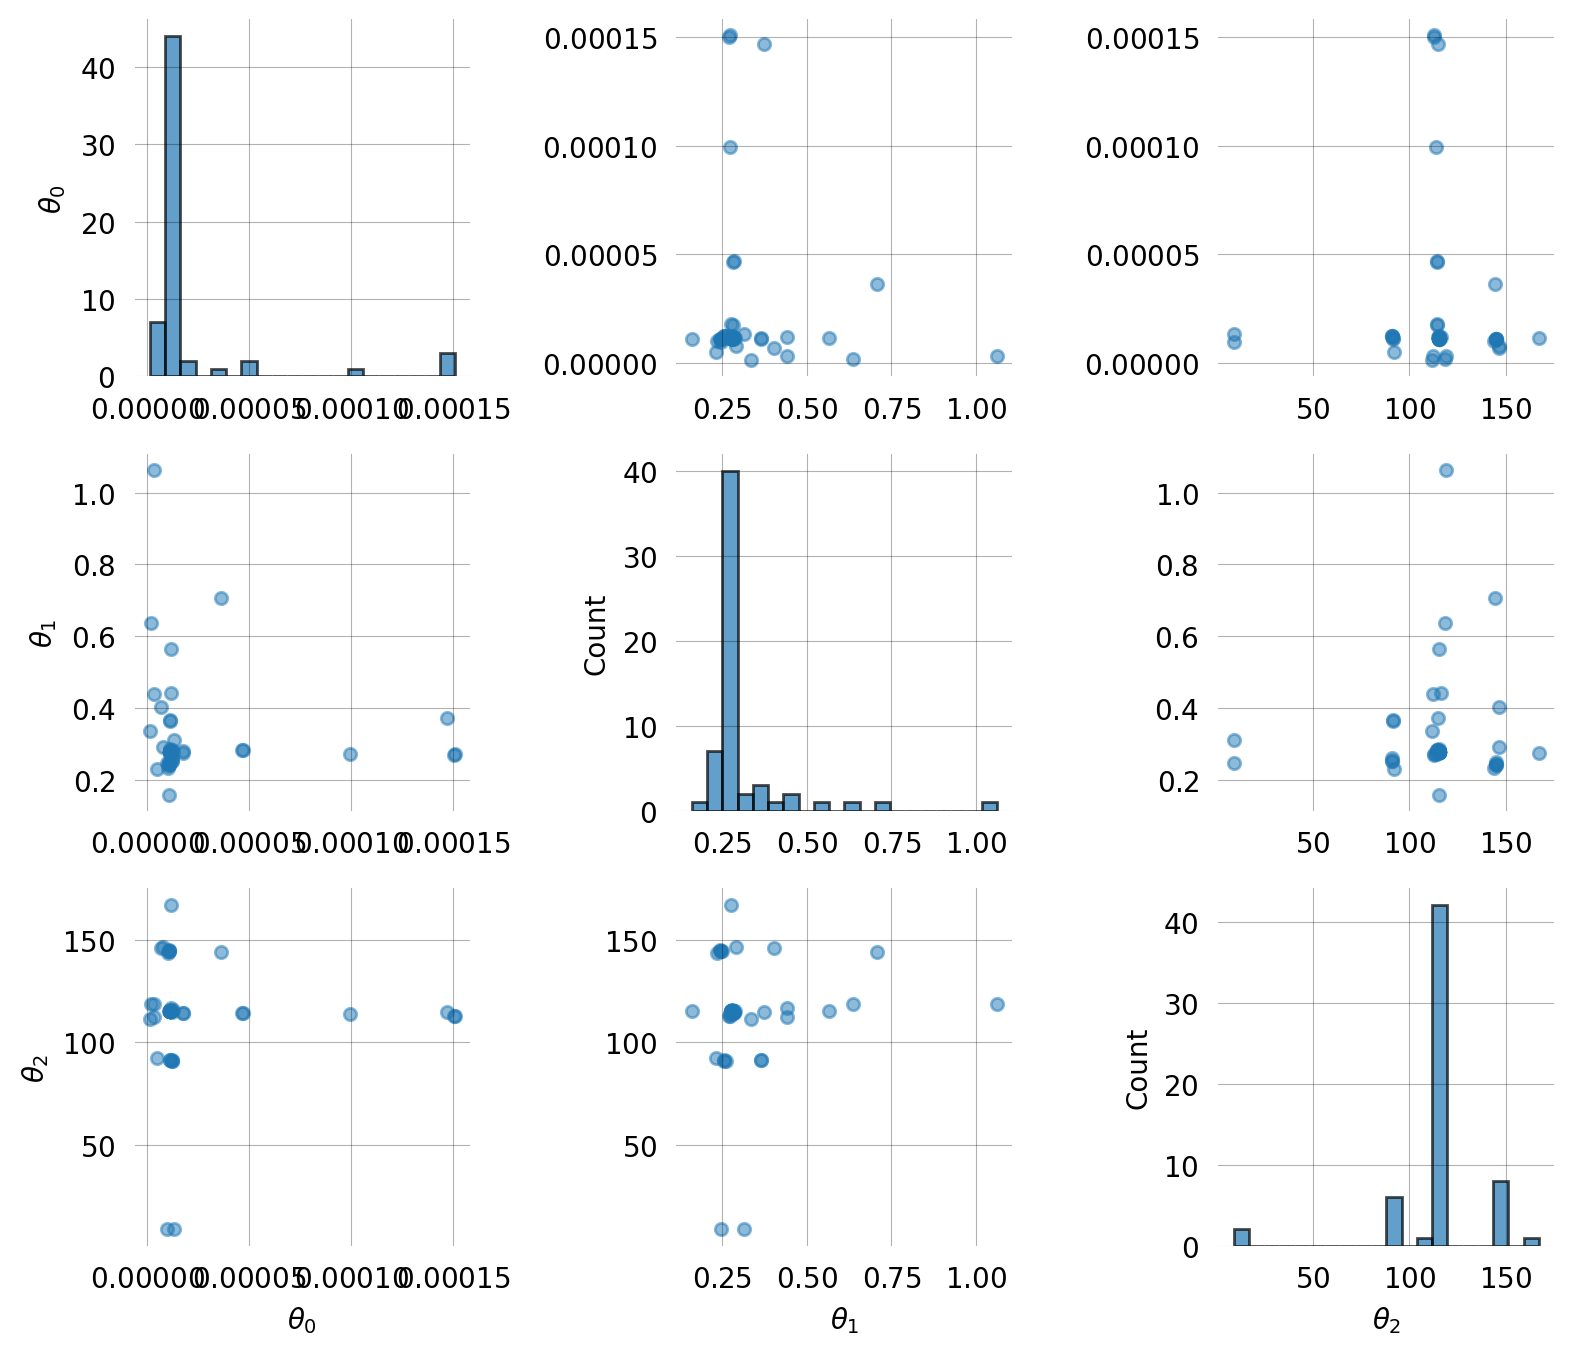

In [9]:
sv_im.plot_convergence()
sv_im.plot_pairwise()

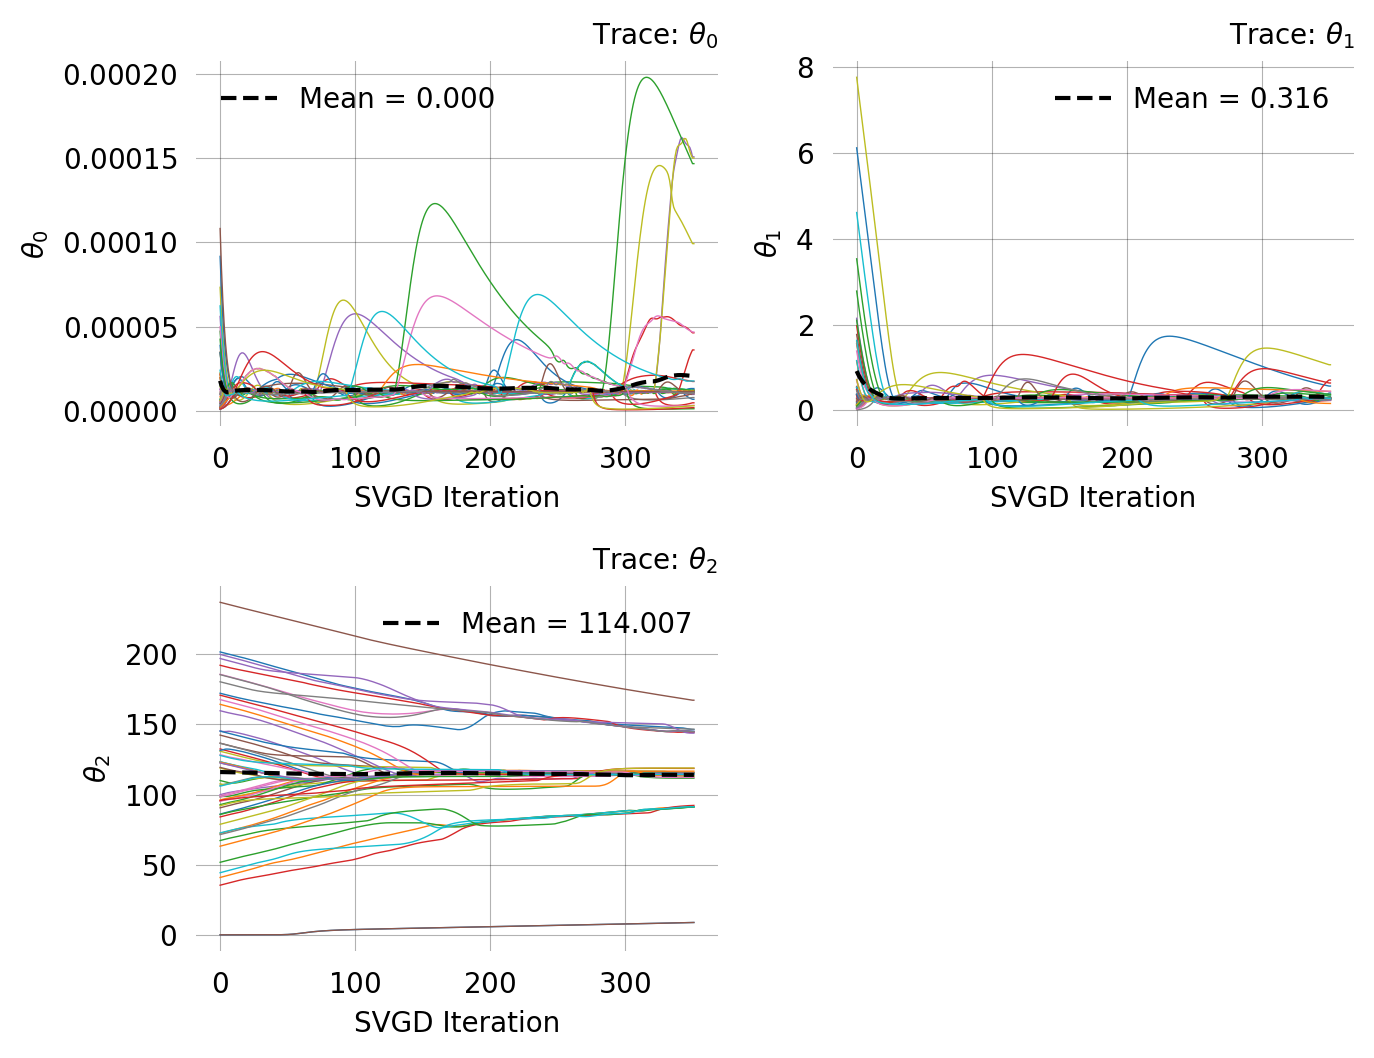

In [10]:
sv_im.plot_trace()

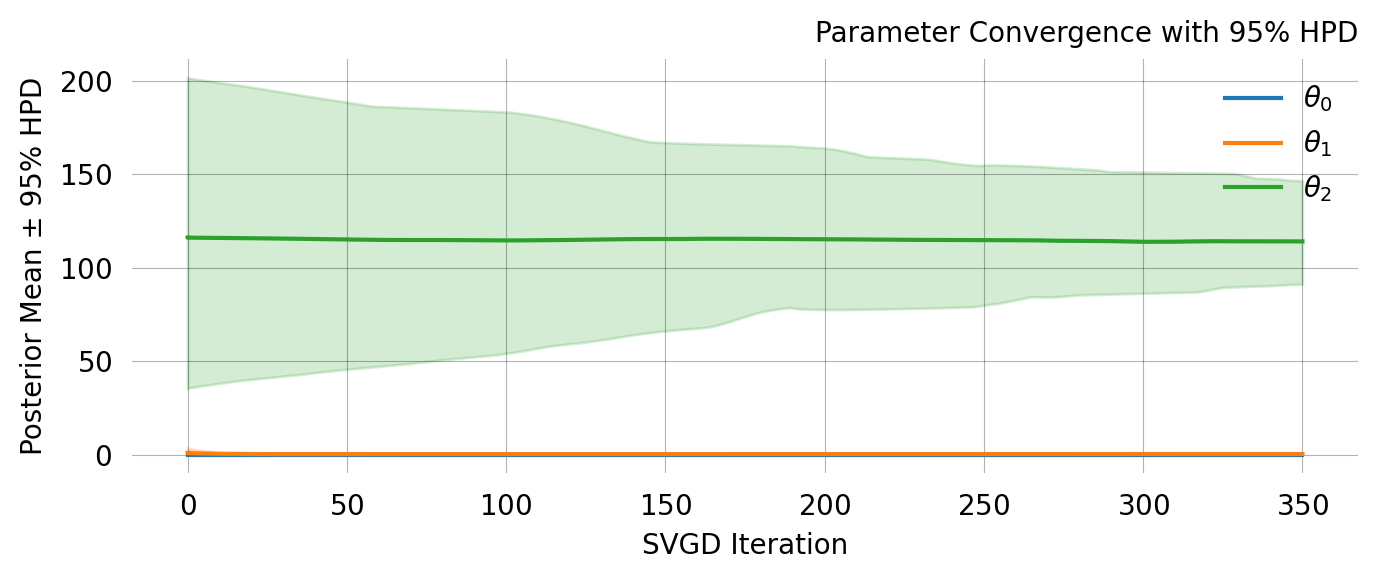

In [11]:
sv_im.plot_ci()

## Tidsinhomogen 3-epoke model

Vuderinger fra NB05:

- Epoker ved 0, 50k og 200k år
- epoch_switch_rate $= 15/t_{coal}$
- $n = 4$ (tidsinhomogen model er beregningstung for stor $n$)
- $3$ frie $N_e$ parametre per population

In [12]:
all_pairs_ti = partial(combinations_with_replacement, r=2)

baboon_years = [0, 50_000, 200_000]
n_epochs     = len(baboon_years)
n_ti         = 4

indexer_ti = StateIndexer(
    lineages=[Property("ton", min_value=1, max_value=n_ti)],
    slots=["epoch"],
)
ipv_ti = [0] * indexer_ti.state_length
ipv_ti[indexer_ti.props_to_index(ton=1)] = n_ti

def coal_epoch(state, epoch_idx=None, indexer=None):
    T = []
    ep = int(epoch_idx)
    if state[indexer.epoch] != ep: return T
    for i, j in all_pairs_ti(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)
        if state.sum() <= 1: continue
        same = int(pi.ton == pj.ton)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy(); new[i] -= 1; new[j] -= 1
        k = indexer.lineages.props_to_index(ton=pi.ton + pj.ton)
        if k < indexer.lineages.state_length: new[k] += 1
        coeff = [0.0] * (n_epochs + 1)
        coeff[ep] = state[i] * (state[j] - same) / (1 + same)
        T.append([new, coeff])
    return T

g_ti   = Graph(coal_epoch, ipv=ipv_ti, epoch_idx=0, indexer=indexer_ti)
n_p_ti = g_ti.param_length()
print(f"3-epoke graf: {g_ti.vertices_length()} tilstande, {n_p_ti} parametre")

# Find korrekte nøgler automatisk
ti_pop_keys = {
    'cyno':   next(k for k in populations if 'cyno'   in k.lower()),
    'kindae': next(k for k in populations if 'kindae' in k.lower()),
    'anubis': next(k for k in populations if 'anubis' in k.lower()),
}
print(f"Bruger: {list(ti_pop_keys.values())}")

results_ti = {}
for pop_label, pop_key in ti_pop_keys.items():
    df_pop = populations[pop_key]
    N_ref  = N_ref_dict[pop_key]
    ep_coal = baboon_years[1] / (2 * N_ref * GEN)
    sw_rate = 15.0 / ep_coal if ep_coal > 0 else 10.0

    if n_p_ti == 4:
        init_ti  = [1.0, 1.0, 1.0, sw_rate]
        fixed_ti = [(3, sw_rate)]
        prior_ti = [GaussPrior(ci=[0.1, 10.0])] * 3 + [None]
    else:
        init_ti  = [1.0, 1.0, 1.0]
        fixed_ti = []
        prior_ti = [GaussPrior(ci=[0.1, 10.0])] * 3


    obs_ti = sfs_to_tmrca(df_pop, n_obs=3000, n_sub=n_ti)
    g_ti.update_weights(init_ti)
    sv_ti = g_ti.svgd(obs_ti, fixed=fixed_ti, prior=prior_ti,
                       optimizer=OPT, n_particles=N_PART, n_iterations=N_ITER_TI)
    res_ti = sv_ti.get_results()
    results_ti[pop_key] = (res_ti, N_ref)

    Ne_ep = [round(N_ref / res_ti['theta_mean'][k].item()) for k in range(3)]
    print(f"{pop_key:<22}: ep0={Ne_ep[0]:>8,}  ep1={Ne_ep[1]:>8,}  ep2={Ne_ep[2]:>8,}")


P_anubis              : ep0=  62,887  ep1=  11,249  ep2=  11,279


## Joint probability-inferens

Vuderinger fra NB06:

- $\mu=1.0$, limit $=3$: deficit $< 1\%$ 
- Manuel GaussPrior: DataPrior kollapser numerisk ved joint 
- Sensitivitetsanalyse over $\mu \in {0.7, 1.0, 1.5}$ 
- Gevinst størst ved lav $\theta$ og få observationer

In [ ]:
all_pairs_jp = partial(combinations_with_replacement, r=2)
n_jp = 4  # subsampled til 4 for joint-beregning

indexer_jp = StateIndexer(
    lineage=[Property('descendants', min_value=1, max_value=n_jp)]
)

@with_ipv([n_jp]+[0]*(n_jp-1))
def coal_jp(state):
    T = []
    for i, j in all_pairs_jp(indexer_jp.lineage):
        p1 = indexer_jp.lineage.index_to_props(i)
        p2 = indexer_jp.lineage.index_to_props(j)
        same = int(i==j)
        if same and state[i]<2: continue
        if not same and (state[i]<1 or state[j]<1): continue
        new = state.copy(); new[i]-=1; new[j]-=1
        des = indexer_jp.lineage.props_to_index(descendants=p1.descendants+p2.descendants)
        if des < indexer_jp.lineage.state_length: new[des] += 1
        T.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return T

g_jp = Graph(coal_jp)
mu_jp = 1.0; lim_jp = 3

# Brug korrekt theta fra den rettede svgd_results
th_jp_ref = svgd_results['P_cynocephalus']['theta']

print(f"Joint: mu={mu_jp}, limit={lim_jp}")
print(f"theta_ref = {th_jp_ref:.8f} (Ne~{th_jp_ref/(4*MU):,.0f})")

jp = g_jp.joint_prob_graph(
    indexer_jp, tot_reward_limit=lim_jp, mutation_rate=mu_jp)
jp.update_weights([th_jp_ref, mu_jp])
tab_jp  = jp.joint_prob_table()
deficit = float(1 - tab_jp['prob'].sum())

print(f"Deficit = {deficit:.5f} "
      f"({'OK' if deficit < 0.05 else 'FOR HØJT — øg tot_reward_limit'})")
print(f"Observationstyper: {len(tab_jp)}")

# Automatisk øg limit hvis deficit for højt
if deficit > 0.05:
    for lim_try in [4, 5, 6, 7]:
        jp = g_jp.joint_prob_graph(
            indexer_jp, tot_reward_limit=lim_try, mutation_rate=mu_jp)
        jp.update_weights([th_jp_ref, mu_jp])
        tab_jp  = jp.joint_prob_table()
        deficit = float(1 - tab_jp['prob'].sum())
        print(f"  limit={lim_try}: deficit={deficit:.5f} "
              f"({'OK' if deficit < 0.05 else 'stadig for højt'})")
        if deficit < 0.05:
            lim_jp = lim_try
            print(f"  Bruger limit={lim_jp}")
            break

Joint: mu=1.0, limit=3
Deficit = 0.59313 (FOR HØJT)
Observationstyper: 20


In [15]:
def df_to_joint_obs(df, n_sub=4, n_obs=1000, seed=42):
    rng = np.random.default_rng(seed)
    der = df['derived_count'].values.astype(int)
    tot = df['nr_samples'].values.astype(int)
    obs = []
    for idx in rng.integers(0, len(df), n_obs*50):
        if len(obs) >= n_obs: break
        n, ac = tot[idx], der[idx]
        if n < n_sub: continue
        k = rng.hypergeometric(ac, n-ac, n_sub)
        if k == 0 or k == n_sub: continue
        vec = [0]*n_sub; vec[k-1] = 1
        obs.append(vec)
    return obs

# Sensitivitetsanalyse over mu
print("Sensitivitetsanalyse over mu for P. cynocephalus:")
for pop_name in ['P_cynocephalus', 'P_kindae', 'P_anubis']:
    df_pop   = populations[pop_name]
    th_ref   = svgd_results[pop_name]['theta']
    obs_pop  = df_to_joint_obs(df_pop, n_obs=1000)
    print(f"\n{pop_name} (theta_ref={th_ref:.5f}):")
    for mu_test in [0.7, 1.0, 1.5]:
        jp_test = g_jp.joint_prob_graph(indexer_jp, tot_reward_limit=lim_jp,
                                         mutation_rate=mu_test)
        # GaussPrior 
        prior_jp = [GaussPrior(ci=[th_ref*0.2, th_ref*5]), None]
        sv_jp = jp_test.svgd(obs_pop, fixed=[(1, mu_test)], prior=prior_jp,
                              optimizer=OPT, n_iterations=200)
        res_jp = sv_jp.get_results()
        m = res_jp['theta_mean'][0].item(); s = res_jp['theta_std'][0].item()
        bias = (m - th_ref)/th_ref*100
        print(f"  mu={mu_test}: theta={m:.5f}+/-{s:.5f}  Ne~{1/m:,.0f}  bias={bias:+.1f}%")

  mu=1.5: theta=5.96022+/-0.22553  Ne~0  bias=+674.9%


In [16]:
def build_coal_graph(n):
    @with_ipv([n] + [0]*(n-1))
    def coal(state):
        T = []
        for i in range(state.size):
            for j in range(i, state.size):
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i]<1 or state[j]<1): continue
                new = state.copy(); new[i]-=1; new[j]-=1; new[i+j+1]+=1
                T.append((new, [state[i]*(state[j]-same)/(1+same)]))
        return T
    return Graph(coal)

In [ ]:
# Gevinst: joint probability vs. TMRCA per population
print("Gevinst: joint probability vs. TMRCA per population")
print(f"Bruger limit={lim_jp}, mu={mu_jp}, deficit={deficit:.5f}")
print()
print(f"{'Population':<22}  {'TMRCA std':>10}  "
      f"{'Joint std':>10}  {'Gevinst procent':>10}")

for name in ['P_cynocephalus', 'P_kindae', 'P_anubis']:
    if name not in populations:
        continue
    df_pop  = populations[name]
    th_ref  = svgd_results[name]['theta']

    # TMRCA
    data_t = allele_counts_to_sfs_obs(df_pop, n_sub=4, n_obs=1000)
    g_t    = build_coal_graph(4)
    rewards_t = g_t.states().T[:-1]
    g_t.update_weights([th_ref])
    sparse_t = dense_to_sparse(
        np.column_stack([
            np.where(data_t == k+1, data_t, np.nan)
            for k in range(3)
        ])
    )
    prior_t = GaussPrior(ci=[th_ref * 0.2, th_ref * 5])
    sv_t    = g_t.svgd(
        sparse_t, rewards=rewards_t,
        prior=prior_t, optimizer=Adam(0.25),
        n_iterations=200,
    )
    std_t = sv_t.get_results()['theta_std'].item()

    # Joint
    if deficit < 0.05:
        obs_j   = df_to_joint_obs(df_pop, n_obs=500)
        prior_j = [GaussPrior(ci=[th_ref * 0.2, th_ref * 5]), None]
        jp.update_weights([th_ref, mu_jp])
        sv_j    = jp.svgd(
            obs_j, fixed=[(1, mu_jp)],
            prior=prior_j, optimizer=Adam(0.25),
            n_iterations=200,
        )
        std_j   = sv_j.get_results()['theta_std'][0].item()
        gevinst = (std_t - std_j) / std_t * 100
        print(f"{name:<22}  {std_t:>10.5f}  "
              f"{std_j:>10.5f}  {gevinst:>+10.1f}%")
    else:
        print(f"{name:<22}  {std_t:>10.5f}  "
              f"{'N/A (deficit>5 procent)':>10}  {'N/A':>10}")

## Msprime validering

In [ ]:
## msprime-validering af to-populations modeller

import msprime

def simulate_two_island_tmrca(Ne, m, n_samples=6, n_loci=3000):
    demography = msprime.Demography()
    demography.add_population(name='pop0', initial_size=Ne)
    demography.add_population(name='pop1', initial_size=Ne)
    demography.set_symmetric_migration_rate(['pop0', 'pop1'], m)

    obs = []
    ts_list = msprime.sim_ancestry(
        samples={'pop0': n_samples // 2, 'pop1': n_samples // 2},
        demography=demography,
        num_replicates=n_loci,
        sequence_length=1_000_000,
        recombination_rate=0,
        ploidy=2,
    )
    for ts in ts_list:
        ts_mut = msprime.sim_mutations(ts, rate=MU)
        for var in ts_mut.variants():
            k = int(var.genotypes.sum())
            if 0 < k < n_samples:
                obs.append(float(k))
                break
    return np.array(obs)


def simulate_im_tmrca(Ne, m, t_split_gen, n_samples=6, n_loci=3000):
    demography = msprime.Demography()
    demography.add_population(name='pop0', initial_size=Ne)
    demography.add_population(name='pop1', initial_size=Ne)
    demography.add_population(name='anc',  initial_size=Ne)
    demography.set_symmetric_migration_rate(['pop0', 'pop1'], m)
    demography.add_population_split(
        time=t_split_gen,
        derived=['pop0', 'pop1'],
        ancestral='anc',
    )

    obs = []
    ts_list = msprime.sim_ancestry(
        samples={'pop0': n_samples // 2, 'pop1': n_samples // 2},
        demography=demography,
        num_replicates=n_loci,
        sequence_length=1_000_000,
        recombination_rate=0,
        ploidy=2,
    )
    for ts in ts_list:
        ts_mut = msprime.sim_mutations(ts, rate=MU)
        for var in ts_mut.variants():
            k = int(var.genotypes.sum())
            if 0 < k < n_samples:
                obs.append(float(k))
                break
    return np.array(obs)


# Test 1: To-ø model 
print("=== msprime-validering: To-ø model ===")
ms_scenarios_two = [
    {'Ne': 50_000, 'm': 1e-5, 'label': 'Lav migration'},
    {'Ne': 80_000, 'm': 5e-5, 'label': 'Moderat migration'},
    {'Ne': 50_000, 'm': 1e-4, 'label': 'Høj migration'},
]

ms_rows_two = []
for sc in ms_scenarios_two:
    theta0_true = 4 * sc['Ne'] * MU
    theta1_true = 2 * sc['Ne'] * sc['m']

    data_ms = simulate_two_island_tmrca(
        Ne=sc['Ne'], m=sc['m'], n_samples=N_TWO, n_loci=2000)

    if len(data_ms) < 100:
        print(f"  {sc['label']}: for få observationer ({len(data_ms)})")
        continue

    g_ms = build_two_island(N_TWO)
    rewards_ms = g_ms.states().T[:-1]
    g_ms.update_weights([theta0_true, theta1_true])

    sparse_ms = dense_to_sparse(
        np.column_stack([
            np.where(data_ms == k+1, data_ms, np.nan)
            for k in range(N_TWO - 1)
        ])
    )

    prior_ms = [
        HalfCauchyPrior(ci=theta0_true * 5, prob=0.9),
        HalfCauchyPrior(ci=theta1_true * 5, prob=0.9),
    ]

    sv_ms = g_ms.svgd(
        sparse_ms, rewards=rewards_ms,
        prior=prior_ms, optimizer=Adam(0.1),
        n_particles=60, n_iterations=400,
    )
    res_ms = sv_ms.get_results()
    th0_e  = res_ms['theta_mean'][0].item()
    th1_e  = res_ms['theta_mean'][1].item()
    Ne_e   = th0_e / (4 * MU)

    bias0 = (th0_e - theta0_true) / theta0_true * 100
    bias1 = (th1_e - theta1_true) / theta1_true * 100

    print(f"  {sc['label']}:")
    print(f"    Ne  sand={sc['Ne']:,}  est={Ne_e:,.0f}  "
          f"bias={bias0:+.1f}%")
    print(f"    m   sand={theta1_true:.4f}  est={th1_e:.4f}  "
          f"bias={bias1:+.1f}%")

    ms_rows_two.append({
        'Scenarie':    sc['label'],
        'Ne sand':     sc['Ne'],
        'Ne est.':     round(Ne_e),
        'bias Ne %':   round(bias0, 1),
        'theta1 sand': round(theta1_true, 4),
        'theta1 est.': round(th1_e, 4),
        'bias m %':    round(bias1, 1),
        'n_obs':       len(data_ms),
    })

df_ms_two = pd.DataFrame(ms_rows_two)
print()
print(df_ms_two.to_string(index=False))


# Test 2: IM-model 
print("\n=== msprime-validering: IM-model ===")
Ne_im_test   = 60_000
m_im_test    = 1e-5
t_split_test = 1_300_000 // GEN  # generationer

theta0_im_true   = 4 * Ne_im_test * MU
theta1_im_true   = 2 * Ne_im_test * m_im_test
t_split_coal_true = t_split_test / (2 * Ne_im_test)
sw_rate_true      = 15.0 / t_split_coal_true

data_ms_im = simulate_im_tmrca(
    Ne=Ne_im_test, m=m_im_test,
    t_split_gen=t_split_test,
    n_samples=N_IM, n_loci=2000,
)

print(f"  n_obs={len(data_ms_im)}")
print(f"  Sand: Ne={Ne_im_test:,}  m={m_im_test}  "
      f"t_split={t_split_test*GEN/1e6:.2f} Ma")
print(f"  theta0={theta0_im_true:.8f}  "
      f"theta1={theta1_im_true:.4f}  "
      f"sw_rate={sw_rate_true:.4f}")

if len(data_ms_im) >= 100:
    g_ms_im = build_im_model(N_IM)
    rewards_im_ms = g_ms_im.states().T[:-1]
    g_ms_im.update_weights([theta0_im_true, theta1_im_true, sw_rate_true])

    sparse_ms_im = dense_to_sparse(
        np.column_stack([
            np.where(data_ms_im == k+1, data_ms_im, np.nan)
            for k in range(N_IM - 1)
        ])
    )

    prior_ms_im = [
        HalfCauchyPrior(ci=theta0_im_true * 5, prob=0.9),
        HalfCauchyPrior(ci=2.0, prob=0.9),
        GaussPrior(ci=[sw_rate_true * 0.2, sw_rate_true * 5]),
    ]

    sv_ms_im = g_ms_im.svgd(
        sparse_ms_im, rewards=rewards_im_ms,
        prior=prior_ms_im, optimizer=Adam(0.1),
        n_particles=60, n_iterations=400,
    )
    res_ms_im = sv_ms_im.get_results()
    th0_im_e  = res_ms_im['theta_mean'][0].item()
    th1_im_e  = res_ms_im['theta_mean'][1].item()
    sw_im_e   = res_ms_im['theta_mean'][2].item()

    Ne_im_e       = th0_im_e / (4 * MU) if th0_im_e > 0 else np.nan
    t_split_e_yr  = (15.0 / sw_im_e * 2 * Ne_im_e * GEN
                     if sw_im_e > 0 and Ne_im_e else np.nan)

    print(f"\n  Estimater:")
    print(f"    Ne:      est={Ne_im_e:,.0f}  "
          f"sand={Ne_im_test:,}  "
          f"bias={((Ne_im_e-Ne_im_test)/Ne_im_test*100):+.1f}%")
    print(f"    theta1:  est={th1_im_e:.4f}  "
          f"sand={theta1_im_true:.4f}  "
          f"bias={((th1_im_e-theta1_im_true)/theta1_im_true*100):+.1f}%")
    print(f"    t_split: est={t_split_e_yr/1e6:.3f} Ma  "
          f"sand={t_split_test*GEN/1e6:.3f} Ma  "
          f"bias={((t_split_e_yr-t_split_test*GEN)/(t_split_test*GEN)*100):+.1f}%")

    sv_ms_im.plot_pairwise(
        true_theta=[theta0_im_true, theta1_im_true, sw_rate_true])
    plt.suptitle('msprime-validering: IM-model pairwise posterior',
                 fontsize=11)
    plt.tight_layout()
    plt.show()